# SBI Binned gNFW Parameter Subsets

This notebook follows the same data-vector pipeline as `SBI_binned.ipynb`, but the inferred parameter vector can be any subset of the gNFW evolution parameters below. Edit `SELECTED_PARAM_NAMES` to choose the constrained subspace; the data vector format can remain the same as before.

In [121]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ModuleNotFoundError:
    pd = None

try:
    import torch
except ModuleNotFoundError:
    torch = None

try:
    from sbi.analysis import pairplot
    from sbi.inference import NPE
    from sbi.utils import BoxUniform
except ModuleNotFoundError:
    pairplot = None
    NPE = None
    BoxUniform = None

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Configuration

In [183]:
CWD = Path.cwd().resolve()
if CWD.name == "SBI_analysis":
    PROJECT_ROOT = CWD.parent
elif (CWD / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD
elif (CWD.parent / "SBI_analysis").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

SBI_DIR = PROJECT_ROOT / "SBI_analysis"
if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

FULL_PARAM_NAMES = [
    "P0_A0",
    "P0_alpha_m",
    "P0_alpha_z",
    "xc_A0",
    "xc_alpha_m",
    "xc_alpha_z",
    "beta_A0",
    "beta_alpha_m",
    "beta_alpha_z",
]

# Choose any subset and order here.
SELECTED_PARAM_NAMES = FULL_PARAM_NAMES.copy()
# SELECTED_PARAM_NAMES = ["P0_A0", "xc_A0", "beta_A0"]
# SELECTED_PARAM_NAMES = ["P0_alpha_m", "xc_alpha_m", "beta_alpha_m"]

# Current and older datasets use slightly different names for the same 9 parameters.
PARAM_ALIASES = {
    "P0_A0": ["P0_A0", "P0"],
    "P0_alpha_m": ["P0_alpha_m", "alpha_m_P0"],
    "P0_alpha_z": ["P0_alpha_z", "alpha_z_P0"],
    "xc_A0": ["xc_A0", "xc"],
    "xc_alpha_m": ["xc_alpha_m", "alpha_m_xc"],
    "xc_alpha_z": ["xc_alpha_z", "alpha_z_xc"],
    "beta_A0": ["beta_A0", "beta"],
    "beta_alpha_m": ["beta_alpha_m", "alpha_m_beta"],
    "beta_alpha_z": ["beta_alpha_z", "alpha_z_beta"],
}

FIDUCIAL_PARAM_VALUES = {
    "P0_A0": 18.1,
    "P0_alpha_m": 0.154,
    "P0_alpha_z": -0.758,
    "xc_A0": 0.497,
    "xc_alpha_m": -0.00865,
    "xc_alpha_z": 0.731,
    "beta_A0": 4.35,
    "beta_alpha_m": 0.0393,
    "beta_alpha_z": 0.415,
}

DATA_PATH = PROJECT_ROOT     / "emulator_tSZ" / "outputs" / "binned_32" / "sbi_dataset_100_000.npz"
# DATA_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "ydata_4096" / "sbi_battaglia_y100_4096.npz"

OBS_Y100_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome_fiducial_nside4096_cluster.npy"
OBS_Y102_PATH = PROJECT_ROOT / "HPC_output" / "HalfDome" / "tSZ_HalfDome102_fiducial_nside4096_cluster.npy"

ELL_MIN = 2
ELL_MAX = 4096
DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"

# The emulator-generated dataset is already binned. Set this True only for raw 4096-ell datasets.
DATAVECTOR_BINNING = {
    "enabled": True,
    "mode": "log",
    "n_bins": 32,
    "ell_min": ELL_MIN,
    "ell_max": ELL_MAX,
    "custom_edges": None,
    "statistic": "mean",
    "weighting": "uniform",
}

USE_NOISY_OBSERVED = False
OBSERVED_NOISE_FRACTION_DL = 0.15
RANDOM_SEED = 42
NUM_POSTERIOR_SAMPLES = 40_000
TRAIN_MAX_ROWS = None  # e.g. 20_000 for a faster first pass

print(f"DATA_PATH: {DATA_PATH}")
print(f"exists: {DATA_PATH.exists()}")
print(f"selected parameters ({len(SELECTED_PARAM_NAMES)}): {SELECTED_PARAM_NAMES}")
print(f"device: {DEVICE}")

DATA_PATH: \\wsl.localhost\myrootfs\home\cbllover\HalfDome\emulator_tSZ\outputs\binned_32\sbi_dataset_100_000.npz
exists: True
selected parameters (9): ['P0_A0', 'P0_alpha_m', 'P0_alpha_z', 'xc_A0', 'xc_alpha_m', 'xc_alpha_z', 'beta_A0', 'beta_alpha_m', 'beta_alpha_z']
device: cpu


In [184]:
PROJECT_ROOT

WindowsPath('//wsl.localhost/myrootfs/home/cbllover/HalfDome')

## Helpers

In [185]:
def selected_ell_mask(ell, ell_min=2, ell_max=None):
    ell = np.asarray(ell, dtype=float).reshape(-1)
    mask = ell >= float(ell_min)
    if ell_max is not None:
        mask &= ell <= float(ell_max)
    if not np.any(mask):
        raise ValueError(f"Empty ell selection for ell_min={ell_min}, ell_max={ell_max}")
    return mask


def cl_to_log10_dl(cl, ell, floor=1.0e-40):
    cl = np.asarray(cl, dtype=float)
    ell = np.asarray(ell, dtype=float)
    factor = ell * (ell + 1.0) / (2.0 * math.pi)
    return np.log10(np.maximum(cl * factor, floor))


def gaussian_beam_window(ells, fwhm_arcmin=1.6):
    ells = np.asarray(ells, dtype=float)
    sigma_rad = (float(fwhm_arcmin) / 60.0) * np.pi / 180.0 / np.sqrt(8.0 * np.log(2.0))
    return np.exp(-0.5 * ells * (ells + 1.0) * sigma_rad**2)


def apply_gaussian_beam_to_log10_dl(log10_dl, ell, fwhm_arcmin=1.6):
    beam = gaussian_beam_window(ell, fwhm_arcmin=fwhm_arcmin)
    return np.asarray(log10_dl, dtype=float) + np.log10(np.maximum(beam**2, 1.0e-40))


def npz_scalar_to_str(data, key, default=""):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    if value.shape == ():
        return str(value.item())
    if value.size == 1:
        return str(value.reshape(-1)[0])
    return default


def npz_json_dict(data, key):
    raw = npz_scalar_to_str(data, key, default="")
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {}


def masked_2d_array(data, key, mask):
    values = np.asarray(data[key], dtype=float)
    if values.ndim != 2:
        raise ValueError(f"{key} must be 2D, got shape {values.shape}")
    if values.shape[1] != mask.size:
        raise ValueError(f"{key} has {values.shape[1]} ell columns, expected {mask.size}")
    return values[:, mask]


def resolve_param_name(requested_name, dataset_columns):
    aliases = PARAM_ALIASES.get(requested_name, [requested_name])
    for alias in aliases:
        if alias in dataset_columns:
            return alias
    raise KeyError(f"Could not resolve {requested_name!r}. Available columns: {dataset_columns}")


def jsonable(value):
    if isinstance(value, dict):
        return {str(k): jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [jsonable(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value

## Load Dataset

In [186]:
def load_sbi_dataset(path, ell_min=2, ell_max=4096):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(path)

    with np.load(path, allow_pickle=True) as data:
        if "theta" not in data.files or "ell" not in data.files:
            raise KeyError(f"{path} must contain theta and ell")
        if "theta_columns" in data.files:
            theta_columns = [str(v) for v in np.asarray(data["theta_columns"]).tolist()]
        elif "x_columns" in data.files:
            theta_columns = [str(v) for v in np.asarray(data["x_columns"]).tolist()]
        else:
            raise KeyError(f"{path} is missing theta_columns or x_columns")

        ell_all = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = selected_ell_mask(ell_all, ell_min, ell_max)
        target_kind = npz_scalar_to_str(data, "target_kind", default="")
        binning_config = npz_json_dict(data, "binning_json")

        direct_key = None
        for key in ("x_log10_dl", "x_binned"):
            if key in data.files:
                direct_key = key
                break
        if direct_key is None and "x" in data.files:
            x_candidate = np.asarray(data["x"])
            if x_candidate.ndim == 2 and x_candidate.shape[1] == ell_all.size and ("theta" in data.files):
                target_lower = target_kind.lower()
                if "log10" in target_lower or "binned" in target_lower:
                    direct_key = "x"

        if direct_key is not None:
            x_combined = masked_2d_array(data, direct_key, mask)
            cl_mean = None
            cl_keys = []
            data_vector_label = f"{direct_key} ({target_kind or 'log10(D_l)'})"
        else:
            cl_keys = sorted(key for key in data.files if key.startswith("cl_y"))
            spectra = {key: masked_2d_array(data, key, mask) for key in cl_keys}
            if spectra:
                if len({arr.shape for arr in spectra.values()}) != 1:
                    raise ValueError("C_l seed arrays have inconsistent shapes")
                cl_mean = np.mean(np.stack(list(spectra.values()), axis=0), axis=0)
            elif "cl_stack" in data.files:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)[:, :, mask]
                cl_mean = np.mean(cl_stack, axis=1)
            elif "cl_mean" in data.files:
                cl_mean = masked_2d_array(data, "cl_mean", mask)
            else:
                raise KeyError(f"{path} has no x_log10_dl/x_binned/x or C_l arrays")
            x_combined = cl_to_log10_dl(cl_mean, ell_all[mask])
            data_vector_label = "C_l converted to log10(D_l)"

        dataset = {
            "theta": np.asarray(data["theta"], dtype=np.float32),
            "theta_columns": theta_columns,
            "ell": ell_all[mask].astype(np.float32),
            "x": np.asarray(x_combined, dtype=np.float32),
            "cl_mean": cl_mean,
            "cl_keys": cl_keys,
            "target_kind": target_kind,
            "data_vector_label": data_vector_label,
            "binning_config": binning_config,
            "is_prebinned": bool(direct_key is not None and ("binned" in target_kind.lower() or "bin_counts" in data.files or direct_key == "x_binned")),
            "source_path": str(path),
        }

        for key in ("bin_counts", "bin_ell_min", "bin_ell_max", "prior_low", "prior_high"):
            if key in data.files:
                values = np.asarray(data[key])
                if key.startswith("bin_") and values.ndim == 1 and values.shape[0] == ell_all.size:
                    values = values[mask]
                dataset[key] = values
        if "prior_bounds_json" in data.files:
            dataset["prior_bounds_json"] = npz_json_dict(data, "prior_bounds_json")

    if dataset["theta"].shape[0] != dataset["x"].shape[0]:
        raise ValueError("theta rows and data-vector rows do not match")
    return dataset


dataset = load_sbi_dataset(DATA_PATH, ell_min=ELL_MIN, ell_max=ELL_MAX)
dataset_columns = list(dataset["theta_columns"])
source_param_names = [resolve_param_name(name, dataset_columns) for name in SELECTED_PARAM_NAMES]
source_param_indices = [dataset_columns.index(name) for name in source_param_names]

theta_np = np.ascontiguousarray(dataset["theta"][:, source_param_indices], dtype=np.float32)
x_np = np.ascontiguousarray(dataset["x"], dtype=np.float32)
ell_np = np.ascontiguousarray(dataset["ell"], dtype=np.float32)
param_names = list(SELECTED_PARAM_NAMES)

print("dataset theta columns:", dataset_columns)
print("selected display names:", param_names)
print("selected source names:", source_param_names)
print("theta_np:", theta_np.shape)
print("x_np:", x_np.shape, dataset["data_vector_label"])
print("ell_np:", ell_np.shape, float(ell_np[0]), float(ell_np[-1]))
print("pre-binned dataset:", dataset["is_prebinned"])

dataset theta columns: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
selected display names: ['P0_A0', 'P0_alpha_m', 'P0_alpha_z', 'xc_A0', 'xc_alpha_m', 'xc_alpha_z', 'beta_A0', 'beta_alpha_m', 'beta_alpha_z']
selected source names: ['P0', 'alpha_m_P0', 'alpha_z_P0', 'xc', 'alpha_m_xc', 'alpha_z_xc', 'beta', 'alpha_m_beta', 'alpha_z_beta']
theta_np: (100000, 9)
x_np: (100000, 32) x_log10_dl (binned_log10_D_ell)
ell_np: (32,) 2.0 3662.0
pre-binned dataset: True


## Prior And Fiducial Point

In [187]:
def selected_prior_bounds(dataset, selected_names, source_names, source_indices):
    if "prior_low" in dataset and "prior_high" in dataset:
        low_all = np.asarray(dataset["prior_low"], dtype=np.float32).reshape(-1)
        high_all = np.asarray(dataset["prior_high"], dtype=np.float32).reshape(-1)
        if low_all.size == len(dataset["theta_columns"]) and high_all.size == len(dataset["theta_columns"]):
            return low_all[source_indices], high_all[source_indices], "dataset prior_low/prior_high"

    bounds = dataset.get("prior_bounds_json", {}) or {}
    if bounds:
        low = []
        high = []
        for display_name, source_name in zip(selected_names, source_names):
            key = display_name if display_name in bounds else source_name
            if key not in bounds:
                break
            low.append(bounds[key][0])
            high.append(bounds[key][1])
        else:
            return np.asarray(low, dtype=np.float32), np.asarray(high, dtype=np.float32), "prior_bounds_json"

    # Last-resort fallback for exploratory work when the NPZ does not carry the exact prior.
    low = np.nanmin(theta_np, axis=0).astype(np.float32)
    high = np.nanmax(theta_np, axis=0).astype(np.float32)
    pad = np.maximum(1.0e-6, 0.01 * (high - low))
    print("Warning: prior bounds were inferred from sample min/max. Prefer saving prior_low/prior_high in the NPZ.")
    return low - pad, high + pad, "sample min/max + 1% padding"


prior_low_np, prior_high_np, prior_source = selected_prior_bounds(
    dataset,
    param_names,
    source_param_names,
    source_param_indices,
)
theta_true_np = np.asarray([FIDUCIAL_PARAM_VALUES[name] for name in param_names], dtype=np.float32)

summary = pd.DataFrame({
    "parameter": param_names,
    "source_column": source_param_names,
    "prior_low": prior_low_np,
    "prior_high": prior_high_np,
    "theta_min": np.nanmin(theta_np, axis=0),
    "theta_max": np.nanmax(theta_np, axis=0),
    "fiducial": theta_true_np,
}) if pd is not None else None

print("prior source:", prior_source)
if summary is not None:
    display(summary)
else:
    for row in zip(param_names, source_param_names, prior_low_np, prior_high_np, theta_true_np):
        print(row)

prior source: dataset prior_low/prior_high


,parameter,source_column,prior_low,prior_high,theta_min,theta_max,fiducial
0,P0_A0,P0,1.832524,34.341221,1.832754,34.340401,18.10000
1,P0_alpha_m,alpha_m_P0,0.000312,0.292251,0.000313,0.292251,0.15400
2,P0_alpha_z,alpha_z_P0,-1.363457,-0.228839,-1.363432,-0.228857,-0.75800
3,xc_A0,xc,0.150011,0.844503,0.150020,0.844502,0.49700
4,xc_alpha_m,alpha_m_xc,-0.099718,0.099795,-0.099716,0.099795,-0.00865
5,xc_alpha_z,alpha_z_xc,0.147393,1.314474,0.147402,1.314468,0.73100
6,beta_A0,beta,3.480627,5.216611,3.480659,5.216607,4.35000
7,beta_alpha_m,alpha_m_beta,-0.019935,0.099767,-0.019934,0.099765,0.03930
8,beta_alpha_z,alpha_z_beta,0.083808,0.745884,0.083815,0.745884,0.41500


## Optional Data-Vector Binning

In [188]:
def _bin_weights(ell_values, weighting="uniform"):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = str(weighting).lower()
    if weighting in {"uniform", "none", "flat"}:
        return np.ones_like(ell_values, dtype=np.float64)
    if weighting == "ell":
        return ell_values.astype(np.float64)
    if weighting in {"2ell_plus_1", "modes", "mode_count"}:
        return 2.0 * ell_values + 1.0
    raise ValueError("weighting must be 'uniform', 'ell', or '2ell_plus_1'")


def _make_bin_edges(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    ell_min = max(float(config.get("ell_min", ell_values.min())), float(ell_values.min()))
    ell_max = min(float(config.get("ell_max", ell_values.max())), float(ell_values.max()))
    mode = str(config.get("mode", "log")).lower()
    if mode == "custom" or config.get("custom_edges") is not None:
        edges = np.asarray(config["custom_edges"], dtype=np.float64)
    elif mode == "log":
        edges = np.geomspace(ell_min, ell_max, int(config.get("n_bins", 32)) + 1)
    elif mode == "linear":
        edges = np.linspace(ell_min, ell_max, int(config.get("n_bins", 32)) + 1)
    else:
        raise ValueError("mode must be 'log', 'linear', or 'custom'")
    edges = np.unique(edges)
    if edges.size < 2 or np.any(np.diff(edges) <= 0):
        raise ValueError("Binning edges must be strictly increasing")
    return edges


def _split_members_to_target(members, ell_values, target_n_bins):
    members = list(members)
    target_n_bins = int(target_n_bins)
    log_ell = np.log(np.maximum(np.asarray(ell_values, dtype=np.float64), 1.0))
    while len(members) < target_n_bins:
        splittable = [i for i, idx in enumerate(members) if idx.size > 1]
        if not splittable:
            break
        widest = max(splittable, key=lambda i: log_ell[members[i][-1]] - log_ell[members[i][0]])
        idx = members[widest]
        midpoint = 0.5 * (log_ell[idx[0]] + log_ell[idx[-1]])
        split_at = int(np.searchsorted(log_ell[idx], midpoint, side="right"))
        split_at = min(max(split_at, 1), idx.size - 1)
        members[widest : widest + 1] = [idx[:split_at], idx[split_at:]]
    return members


def summarize_members(members, ell_values, weighting="uniform", centers=None):
    out_centers, counts, bin_min, bin_max = [], [], [], []
    for idx in members:
        weights = _bin_weights(ell_values[idx], weighting)
        out_centers.append(np.average(ell_values[idx], weights=weights))
        counts.append(idx.size)
        bin_min.append(ell_values[idx[0]])
        bin_max.append(ell_values[idx[-1]])
    return {
        "centers": np.asarray(out_centers if centers is None else centers, dtype=np.float32),
        "counts": np.asarray(counts, dtype=np.int64),
        "bin_min": np.asarray(bin_min, dtype=np.float32),
        "bin_max": np.asarray(bin_max, dtype=np.float32),
    }


def make_ell_binning(ell_values, config):
    ell_values = np.asarray(ell_values, dtype=np.float64)
    weighting = config.get("weighting", "uniform")
    if not bool(config.get("enabled", True)):
        members = [np.array([i], dtype=np.int64) for i in range(ell_values.size)]
        return {"enabled": False, "members": members, **summarize_members(members, ell_values, weighting)}
    edges = _make_bin_edges(ell_values, config)
    selected = (ell_values >= edges[0]) & (ell_values <= edges[-1])
    bin_index = np.digitize(ell_values, edges, right=False) - 1
    bin_index[ell_values == edges[-1]] = edges.size - 2
    members = [np.flatnonzero(selected & (bin_index == i)).astype(np.int64) for i in range(edges.size - 1)]
    members = [idx for idx in members if idx.size]
    members = _split_members_to_target(members, ell_values, int(config.get("n_bins", len(members))))
    return {"enabled": True, "members": members, **summarize_members(members, ell_values, weighting)}


def make_binning_from_bin_ranges(bin_min, bin_max, centers, weighting="uniform"):
    bin_min = np.asarray(bin_min, dtype=np.float64)
    bin_max = np.asarray(bin_max, dtype=np.float64)
    centers = np.asarray(centers, dtype=np.float64)
    source_ell = np.arange(int(np.floor(bin_min.min())), int(np.ceil(bin_max.max())) + 1, dtype=np.float64)
    members = []
    for lo, hi, center in zip(bin_min, bin_max, centers):
        idx = np.flatnonzero((source_ell >= lo) & (source_ell <= hi))
        if idx.size == 0:
            idx = np.array([int(np.argmin(np.abs(source_ell - center)))], dtype=np.int64)
        members.append(idx.astype(np.int64))
    return source_ell.astype(np.float32), {"enabled": True, "members": members, **summarize_members(members, source_ell, weighting, centers=centers)}


def bin_last_axis(values, binning, ell_values, statistic="mean", weighting="uniform"):
    values = np.asarray(values)
    pieces = []
    for idx in binning["members"]:
        selected = values[..., idx]
        if statistic == "mean":
            pieces.append(np.average(selected, axis=-1, weights=_bin_weights(np.asarray(ell_values)[idx], weighting)))
        elif statistic == "median":
            pieces.append(np.median(selected, axis=-1))
        else:
            raise ValueError("statistic must be 'mean' or 'median'")
    return np.stack(pieces, axis=-1)

In [189]:
ell_loaded_np = ell_np.copy()
x_loaded_np = x_np.copy()

ell_binning = make_ell_binning(ell_loaded_np, DATAVECTOR_BINNING)
if DATAVECTOR_BINNING["enabled"]:
    x_np = np.ascontiguousarray(
        bin_last_axis(
            x_loaded_np,
            ell_binning,
            ell_loaded_np,
            statistic=DATAVECTOR_BINNING["statistic"],
            weighting=DATAVECTOR_BINNING["weighting"],
        ),
        dtype=np.float32,
    )
    ell_np = np.ascontiguousarray(ell_binning["centers"], dtype=np.float32)

source_binning = dataset.get("binning_config", {}) or {}
observed_statistic = source_binning.get("statistic", DATAVECTOR_BINNING["statistic"])
observed_weighting = source_binning.get("weighting", DATAVECTOR_BINNING["weighting"])
if all(key in dataset for key in ("bin_ell_min", "bin_ell_max")):
    observed_source_ell_np, observed_binning = make_binning_from_bin_ranges(
        dataset["bin_ell_min"],
        dataset["bin_ell_max"],
        ell_np,
        weighting=observed_weighting,
    )
    observed_binning_label = "dataset bin ranges"
elif DATAVECTOR_BINNING["enabled"]:
    observed_source_ell_np = ell_loaded_np
    observed_binning = ell_binning
    observed_binning_label = "notebook binning"
else:
    observed_source_ell_np = ell_np
    observed_binning = make_ell_binning(ell_np, {**DATAVECTOR_BINNING, "enabled": False})
    observed_binning_label = "active ell grid only"

BINNING_SUMMARY = {
    "dataset_prebinned": bool(dataset.get("is_prebinned", False)),
    "notebook_binning_enabled": bool(DATAVECTOR_BINNING["enabled"]),
    "n_bins": int(ell_np.size),
    "observed_binning_label": observed_binning_label,
    "bin_counts": observed_binning["counts"],
    "bin_ell_min": observed_binning["bin_min"],
    "bin_ell_max": observed_binning["bin_max"],
}

print("active x_np:", x_np.shape)
print("active ell_np:", ell_np.shape, float(ell_np[0]), float(ell_np[-1]))
print("observed binning:", observed_binning_label)

active x_np: (100000, 32)
active ell_np: (32,) 2.0 3662.0
observed binning: dataset bin ranges


## Observed Fiducial Vector

In [190]:
def load_observed_spectrum_for_ell(path, ell):
    path = Path(path).expanduser()
    if not path.is_file():
        raise FileNotFoundError(path)
    values = np.asarray(np.load(path), dtype=float).reshape(-1)
    ell_index = np.asarray(ell, dtype=np.int64)
    if ell_index.min() < 0 or ell_index.max() >= values.size:
        raise ValueError(f"{path} has length {values.size}, cannot index ell={ell_index.min()}-{ell_index.max()}")
    return values[ell_index]


obs_y100_dl = load_observed_spectrum_for_ell(OBS_Y100_PATH, observed_source_ell_np)
obs_y102_dl = load_observed_spectrum_for_ell(OBS_Y102_PATH, observed_source_ell_np) if OBS_Y102_PATH.is_file() else obs_y100_dl
obs_mean_dl = (obs_y100_dl)
obs_log10_source = np.log10(np.maximum(obs_mean_dl, 1.0e-40))

x_observed_log10_np = np.ascontiguousarray(
    bin_last_axis(
        obs_log10_source,
        observed_binning,
        observed_source_ell_np,
        statistic=observed_statistic,
        weighting=observed_weighting,
    ),
    dtype=np.float32,
)
x_observed_np = np.power(10.0, x_observed_log10_np).astype(np.float32)

rng = np.random.default_rng(RANDOM_SEED)
x_observed_noisy_np = np.ascontiguousarray(
    x_observed_np + rng.normal(0.0, OBSERVED_NOISE_FRACTION_DL * x_observed_np, size=x_observed_np.shape),
    dtype=np.float32,
)
x_observed_noisy_log10_np = np.log10(np.maximum(x_observed_noisy_np, 1.0e-40)).astype(np.float32)
x_o_np = x_observed_noisy_log10_np if USE_NOISY_OBSERVED else x_observed_log10_np

print("observed clean:", x_observed_log10_np.shape)
print("observed noisy:", x_observed_noisy_log10_np.shape)
print("matches x shape:", x_o_np.shape == x_np.shape[1:])
print("using noisy observed:", USE_NOISY_OBSERVED)

observed clean: (32,)
observed noisy: (32,)
matches x shape: True
using noisy observed: False


## Torch Tensors And Prior

In [191]:
if torch is None or NPE is None or BoxUniform is None:
    raise ModuleNotFoundError("Install torch and sbi in this kernel before running training cells.")

n_train_rows = theta_np.shape[0] if TRAIN_MAX_ROWS is None else min(int(TRAIN_MAX_ROWS), theta_np.shape[0])
theta_train_np = np.ascontiguousarray(theta_np[:n_train_rows], dtype=np.float32)
x_train_np = np.ascontiguousarray(x_np[:n_train_rows], dtype=np.float32)

theta = torch.from_numpy(theta_train_np).to(DEVICE)
x = torch.from_numpy(x_train_np).to(DEVICE)
x_o = torch.from_numpy(np.ascontiguousarray(x_o_np, dtype=np.float32)).to(DEVICE)
prior_low = torch.from_numpy(prior_low_np.astype(np.float32)).to(DEVICE)
prior_high = torch.from_numpy(prior_high_np.astype(np.float32)).to(DEVICE)

try:
    prior = BoxUniform(low=prior_low, high=prior_high, device=DEVICE)
except TypeError:
    prior = BoxUniform(low=prior_low, high=prior_high)

prepared = {
    "theta": theta,
    "x": x,
    "x_observed": x_o,
    "ell": ell_np,
    "param_names": param_names,
    "source_param_names": source_param_names,
    "theta_true": theta_true_np,
    "prior": prior,
    "prior_low": prior_low,
    "prior_high": prior_high,
    "binning": BINNING_SUMMARY,
}

print(theta.dtype, theta.device, theta.shape)
print(x.dtype, x.device, x.shape)
print("x_o:", x_o.shape)

torch.float32 cpu torch.Size([100000, 9])
torch.float32 cpu torch.Size([100000, 32])
x_o: torch.Size([32])


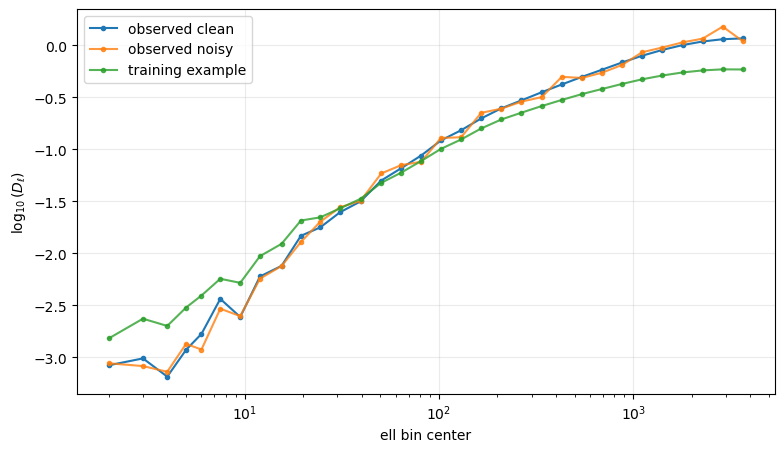

In [ ]:
fig, ax = plt.subplots()
ax.plot(ell_np, prepared["x_observed"]+12, marker="o", ms=3, label="observed clean")
ax.plot(ell_np, x_observed_noisy_log10_np+12, marker="o", ms=3, label="observed noisy", alpha=0.8)
ax.plot(ell_np, prepared["x"][3232]+12, marker="o", ms=3, label="training example", alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("ell bin center")
ax.set_ylabel(r"$\log_{10}(D_\ell)$")
ax.legend()
plt.show()

In [215]:
prepared["theta"][29]

tensor([ 4.0590,  0.2098, -0.2355,  0.4511,  0.0946,  0.4048,  4.1886,  0.0096,
         0.5029])

## Train SBI

In [194]:
x_obs = x_observed_noisy_log10_np
# x_obs = prepared["x_observed"]

torch.manual_seed(RANDOM_SEED)
inference = NPE(prior=prepared["prior"])
density_estimator = inference.append_simulations(prepared["theta"], prepared["x"]).train()
posterior = inference.build_posterior(density_estimator)
samples = posterior.sample((NUM_POSTERIOR_SAMPLES,), x=x_obs)
samples.shape

 Neural network successfully converged after 265 epochs.

  0%|          | 0/40000 [00:00<?, ?it/s]

                    accepted. It may take a long time to collect the remaining
                    39941 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


torch.Size([40000, 9])

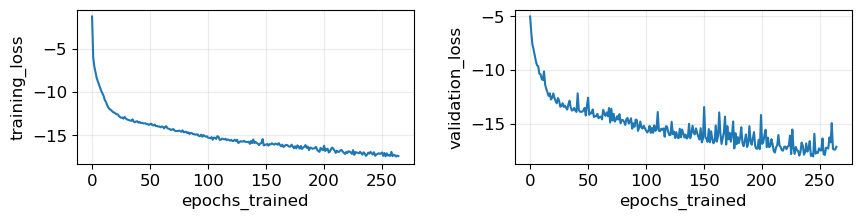

In [198]:
from sbi.analysis import plot_summary

_ = plot_summary(
    inference,
    tags=["training_loss", "validation_loss"],
    figsize=(10, 2),
)

In [178]:
subset_tag = "_".join(param_names)
save_dir = Path("outputs/posteriors/gNFW_subsets")
save_dir.mkdir(parents=True, exist_ok=True)
posterior_save_path = save_dir / f"posterior_{subset_tag}_N{n_train_rows}_bins{ell_np.size}.npy"
np.save(posterior_save_path, samples.detach().cpu().numpy())
print(posterior_save_path)

outputs\posteriors\gNFW_subsets\posterior_P0_A0_P0_alpha_m_P0_alpha_z_xc_A0_xc_alpha_m_xc_alpha_z_beta_A0_beta_alpha_m_beta_alpha_z_N4096_bins32.npy


## Posterior Plot

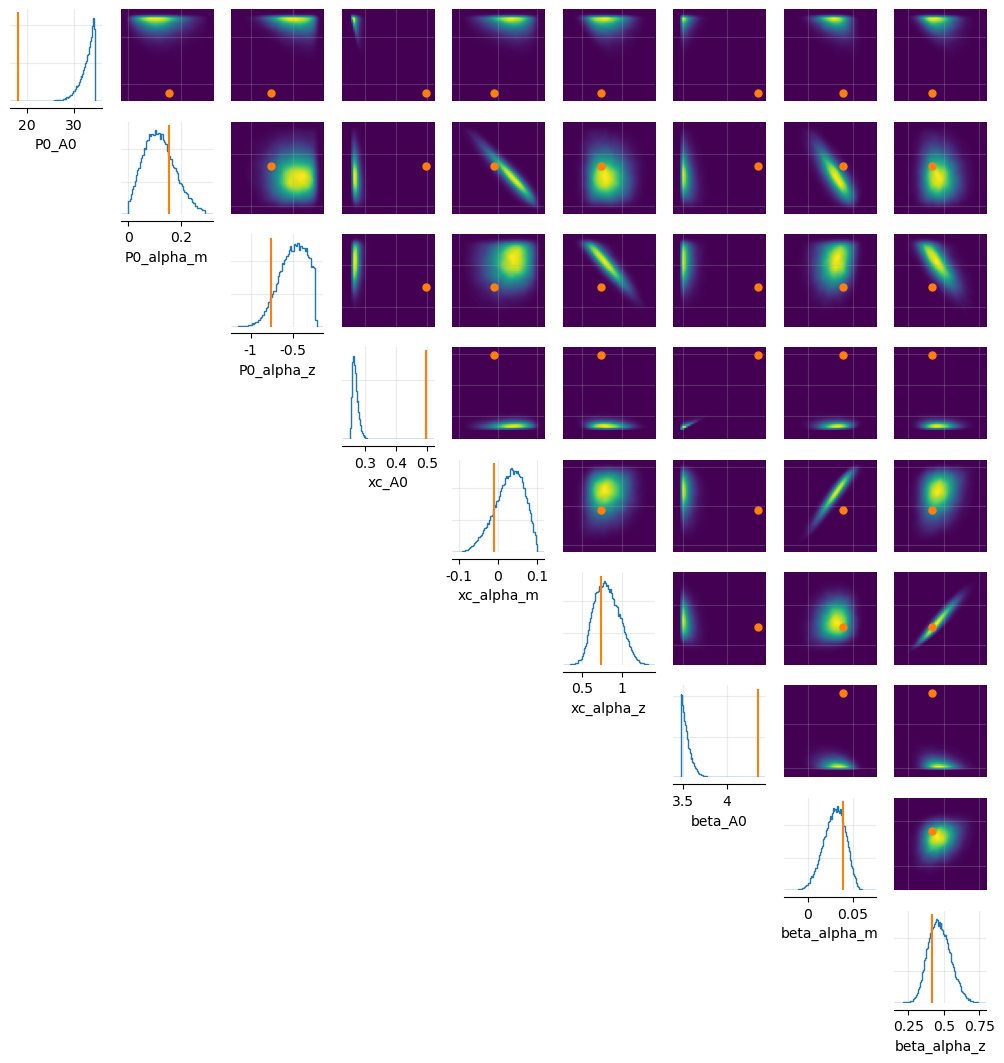

In [196]:
samples_np = samples.detach().cpu().numpy()

if len(param_names) == 1:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(samples_np[:, 0], bins=80, density=True, histtype="stepfilled", alpha=0.45)
    ax.axvline(theta_true_np[0], color="black", lw=1.5, label="fiducial")
    ax.set_xlabel(param_names[0])
    ax.set_ylabel("density")
    ax.legend(frameon=False)
    plt.show()
else:
    if pairplot is None:
        raise ModuleNotFoundError("sbi.analysis.pairplot is not available in this kernel")
    points = torch.as_tensor(theta_true_np.reshape(1, -1), dtype=torch.float32)
    fig, axes = pairplot(
        samples.detach().cpu(),
        labels=param_names,
        points=points,
        figsize=(max(6, 1.4 * len(param_names)), max(6, 1.4 * len(param_names))),
        upper="kde",
    )
    # plt.savefig("posterior_9params_only_noisy_32bins_N60000.png", dpi=300, bbox_inches="tight")
    plt.show()

In [197]:
posterior_np = samples.detach().cpu().numpy()
param_names = list(prepared["param_names"])

true_values = np.asarray(prepared.get("theta_true", theta_true_np), dtype=float).reshape(-1)

summary = pd.DataFrame({
    "parameter": param_names,
    "true": true_values,
    "mean": np.mean(posterior_np, axis=0),
    "median": np.median(posterior_np, axis=0),
    "std": np.std(posterior_np, axis=0),
    "q16": np.percentile(posterior_np, 16, axis=0),
    "q84": np.percentile(posterior_np, 84, axis=0),
    "q2.5": np.percentile(posterior_np, 2.5, axis=0),
    "q97.5": np.percentile(posterior_np, 97.5, axis=0),
})

summary["median - true"] = summary["median"] - summary["true"]
summary["mean - true"] = summary["mean"] - summary["true"]
summary["pull"] = (summary["median"] - summary["true"]) / summary["std"]
summary["true in 68%"] = (summary["true"] >= summary["q16"]) & (summary["true"] <= summary["q84"])
summary["true in 95%"] = (summary["true"] >= summary["q2.5"]) & (summary["true"] <= summary["q97.5"])

pretty = summary.copy()
pretty["68% interval"] = pretty.apply(lambda r: f"[{r['q16']:.4g}, {r['q84']:.4g}]", axis=1)
pretty["95% interval"] = pretty.apply(lambda r: f"[{r['q2.5']:.4g}, {r['q97.5']:.4g}]", axis=1)

pretty = pretty[
    [
        "parameter",
        "true",
        "mean",
        "median",
        "std",
        "68% interval",
        "95% interval",
        "median - true",
        "pull",
        "true in 68%",
        "true in 95%",
    ]
]

display(
    pretty.style
    .format({
        "true": "{:.5g}",
        "mean": "{:.5g}",
        "median": "{:.5g}",
        "std": "{:.5g}",
        "median - true": "{:+.5g}",
        "pull": "{:+.2f}",
    })
    .background_gradient(subset=["pull"], cmap="coolwarm", vmin=-3, vmax=3)
)

,parameter,true,mean,median,std,68% interval,95% interval,median - true,pull,true in 68%,true in 95%
0,P0_A0,18.1,32.571,33.014,1.5807,"[31.1, 34]","[28.5, 34.29]",+14.914,+9.44,False,False
1,P0_alpha_m,0.154,0.11817,0.11351,0.05897,"[0.05732, 0.1795]","[0.01828, 0.2448]",-0.040487,-0.69,True,True
2,P0_alpha_z,-0.758,-0.49888,-0.48321,0.16427,"[-0.6704, -0.323]","[-0.848, -0.2451]",+0.27479,+1.67,False,True
3,xc_A0,0.497,0.26923,0.2675,0.009594,"[0.2602, 0.2784]","[0.2558, 0.2924]",-0.2295,-23.92,False,False
4,xc_alpha_m,-0.00865,0.02867,0.032393,0.037035,"[-0.01003, 0.06685]","[-0.05161, 0.08965]",+0.041043,+1.11,True,True
5,xc_alpha_z,0.731,0.80861,0.79912,0.15511,"[0.648, 0.9721]","[0.5384, 1.125]",+0.068116,+0.44,True,True
6,beta_A0,4.35,3.5461,3.5309,0.057409,"[3.494, 3.6]","[3.483, 3.693]",-0.81912,-14.27,False,False
7,beta_alpha_m,0.0393,0.029313,0.030013,0.011998,"[0.01698, 0.04156]","[0.00431, 0.05037]",-0.009287,-0.77,True,True
8,beta_alpha_z,0.415,0.46781,0.46363,0.078163,"[0.3891, 0.5473]","[0.3282, 0.6305]",+0.048633,+0.62,True,True
